# 💳 Impayé Risk Scoring Model
**Objectif :** Prédire la probabilité qu'une quittance devienne **impayée** *avant* son émission.

**Pourquoi c'est stratégique :**
> Un impayé coûte plus qu'une prime non-encaissée. Il déclenche une procédure de résiliation, une couverture maintenue à découvert, et une charge administrative. L'identifier **avant** permet d'agir en amont : exiger un prélèvement automatique, fractionner différemment, ou appliquer une surprime de risque de paiement.

**Pipeline :**
1. Construction du label & features à la quittance
2. Gestion du déséquilibre sévère (1.3% impayés)
3. Logistic Regression → baseline interprétable
4. XGBoost + LightGBM → performance maximale
5. Calibration des probabilités
6. Score de risque [0–1000] + segmentation
7. SHAP — explication individuelle
8. Simulateur & règles métier

---

## 0. Setup

In [56]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report, f1_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
np.random.seed(42)

print('✅ Setup complet')

✅ Setup complet


## 1. Chargement des Données

In [57]:
def load(filename, date_cols=None):
    import os
    base_dir = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    path = os.path.join(base_dir, filename)
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

em   = load('DWH_FACT_EMISSION.csv',   ['DATE_EMISSION','DATE_EFFET','DATE_ECHEANCE'])
imp  = load('DWH_FACT_IMPAYE.csv',     ['DATE_EMISSION','DATE_SITUATION'])
ann  = load('DWH_FACT_ANNULATION.csv', ['DATE_ANNULATION','DATE_EMISSION'])

## 2. Analyse Exploratoire — Qui ne paie pas ?

In [58]:
# Préparation du DataFrame em_valid avec label impayé et features de base
em_valid = em.copy()
if 'LABEL_IMPAYE' not in em_valid.columns:
    # Construction du label : une quittance est impayée si elle apparaît dans imp
    em_valid['LABEL_IMPAYE'] = em_valid['NUM_QUITTANCE'].isin(imp['NUM_QUITTANCE']).astype(int)
if 'MOIS_ECHEANCE' not in em_valid.columns and 'DATE_ECHEANCE' in em_valid.columns:
    em_valid['MOIS_ECHEANCE'] = em_valid['DATE_ECHEANCE'].dt.month
if 'ANNEE_ECHEANCE' not in em_valid.columns and 'DATE_ECHEANCE' in em_valid.columns:
    em_valid['ANNEE_ECHEANCE'] = em_valid['DATE_ECHEANCE'].dt.year

fig = make_subplots(rows=2, cols=3, subplot_titles=[
    'Taux impayé par Branche',
    'Taux impayé par Bonus/Malus',
    'Taux impayé par Périodicité',
    'Montant prime vs Impayé',
    'Taux impayé par Mois Échéance',
    'Évolution annuelle des impayés'
])

# Par branche
br = em_valid.groupby('BRANCHE')['LABEL_IMPAYE'].mean().sort_values(ascending=True) * 100
fig.add_trace(go.Bar(x=br.values, y=br.index, orientation='h',
                     marker_color='steelblue'), row=1, col=1)

# Par bonus/malus
bm = em_valid.groupby('BONUS_MALUS')['LABEL_IMPAYE'].mean() * 100
fig.add_trace(go.Bar(x=bm.index.astype(str), y=bm.values,
                     marker_color='darkorange'), row=1, col=2)

# Par périodicité
per_map = {'A': 'Annuelle', 'S': 'Semestrielle', 'T': 'Trimestrielle', 'C': 'Mensuelle'}
em_valid['PERIODICITE_LIB'] = em_valid['PERIODICITE'].map(per_map).fillna(em_valid['PERIODICITE'])
per = em_valid.groupby('PERIODICITE_LIB')['LABEL_IMPAYE'].mean().sort_values(ascending=False) * 100
fig.add_trace(go.Bar(x=per.index, y=per.values,
                     marker_color='crimson'), row=1, col=3)

# Montant prime (boxplot proxy via histogram)
em_valid['MT_PTT_CLIP'] = em_valid['MT_PTT'].clip(0, 5000)
fig.add_trace(go.Histogram(x=em_valid[em_valid['LABEL_IMPAYE']==0]['MT_PTT_CLIP'],
                            nbinsx=40, name='Payée', opacity=0.6,
                            marker_color='steelblue'), row=2, col=1)
fig.add_trace(go.Histogram(x=em_valid[em_valid['LABEL_IMPAYE']==1]['MT_PTT_CLIP'],
                            nbinsx=40, name='Impayée', opacity=0.8,
                            marker_color='crimson'), row=2, col=1)

# Par mois échéance
mo = em_valid.groupby('MOIS_ECHEANCE')['LABEL_IMPAYE'].mean() * 100
fig.add_trace(go.Scatter(x=mo.index, y=mo.values, mode='lines+markers',
                          marker_color='teal'), row=2, col=2)

# Par année
yr = em_valid[em_valid['ANNEE_ECHEANCE'].between(2019,2025)].groupby('ANNEE_ECHEANCE')['LABEL_IMPAYE'].mean() * 100
fig.add_trace(go.Bar(x=yr.index.astype(str), y=yr.values,
                     marker_color='purple'), row=2, col=3)

fig.update_layout(height=620, title_text='🔍 Analyse Exploratoire — Qui ne paie pas ?',
                  showlegend=False)
fig.show()

In [59]:
# Table de taux d'impayé par croisement branche × périodicité
pivot = em_valid.pivot_table(
    values='LABEL_IMPAYE',
    index='BRANCHE',
    columns='PERIODICITE_LIB',
    aggfunc='mean'
) * 100

display(
    pivot.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('{:.1f}%')
    .set_caption('Taux d\'impayé (%) — Branche × Périodicité')
)

PERIODICITE_LIB,Annuelle,Mensuelle,Semestrielle,Trimestrielle
BRANCHE,,,,
AUTO,1.4%,1.5%,1.5%,1.1%
IRDS,1.3%,1.1%,1.3%,1.5%
SANTE,1.2%,0.8%,0.6%,0.9%


## 3. Feature Engineering

In [60]:
# Assurez-vous que pol, cli, veh, sin sont chargés avant feature engineering
if 'pol' not in globals():
    pol = load('DIM_POLICE.csv', ['DATE_EFFET','DATE_ECHEANCE'])
if 'cli' not in globals():
    cli = load('DIM_CLIENT.csv', ['DATE_NAISSANCE'])
if 'veh' not in globals():
    veh = load('DIM_VEHICULE.csv', ['DATE_MEC'])
if 'sin' not in globals():
    sin = load('DWH_FACT_SINISTRE.csv', ['DATE_SURVENANCE','DATE_DECLARATION'])

df = em_valid.copy()

# ══════════════════════════════════════════════════════
# BLOC A — Features de la quittance elle-même
# ══════════════════════════════════════════════════════
# Montants
df['MT_PTT']   = df['MT_PTT'].fillna(df['MT_PNET'].fillna(0))
df['LOG_MT_PTT'] = np.log1p(df['MT_PTT'].clip(0))

# Temporel
df['MOIS_EMISSION']    = df['DATE_EMISSION'].dt.month
df['TRIMESTRE_EMISSION'] = df['DATE_EMISSION'].dt.quarter
df['ANNEE_EMISSION']   = df['DATE_EMISSION'].dt.year
df['JOUR_SEMAINE']     = df['DATE_EMISSION'].dt.dayofweek
df['FLAG_FIN_MOIS']    = (df['DATE_EMISSION'].dt.day >= 25).astype(int)

# Numéro d'avenant (>0 = modification du contrat)
df['FLAG_AVN'] = (df['NUM_AVN'] > 0).astype(int)

# Encodage périodicité en risque croissant
per_risk = {'A': 1, 'S': 2, 'T': 3, 'C': 4}  # mensuel = plus risqué
df['PERIODICITE_RISK'] = df['PERIODICITE'].map(per_risk).fillna(2)

# ══════════════════════════════════════════════════════
# BLOC B — Historique de paiement de la police
# (features calculées sur les quittances PRÉCÉDENTES — pas de leakage)
# ══════════════════════════════════════════════════════
df_sorted = df.sort_values(['ID_POLICE', 'DATE_EMISSION'])

# Nb impayés passés sur cette police
df_sorted['POLICE_NB_IMPAYES_HIST'] = (
    df_sorted.groupby('ID_POLICE')['LABEL_IMPAYE']
    .transform(lambda x: x.shift(1).expanding().sum().fillna(0))
)

# Taux d'impayé historique de la police
df_sorted['POLICE_TAUX_IMPAYE_HIST'] = (
    df_sorted.groupby('ID_POLICE')['LABEL_IMPAYE']
    .transform(lambda x: x.shift(1).expanding().mean().fillna(0))
)

# Numéro de quittance dans la séquence de la police (ancienneté)
df_sorted['POLICE_SEQ_QUIT'] = (
    df_sorted.groupby('ID_POLICE').cumcount() + 1
)

df['POLICE_NB_IMPAYES_HIST']  = df_sorted['POLICE_NB_IMPAYES_HIST']
df['POLICE_TAUX_IMPAYE_HIST'] = df_sorted['POLICE_TAUX_IMPAYE_HIST']
df['POLICE_SEQ_QUIT']         = df_sorted['POLICE_SEQ_QUIT']

# ══════════════════════════════════════════════════════
# BLOC C — Historique de paiement du client
# ══════════════════════════════════════════════════════
# Agréger par client (via jointure police → client)
pol_client = pol[['ID_POLICE','ID_CLIENT']].drop_duplicates()
df = df.merge(pol_client, on='ID_POLICE', how='left')

# Impayés passés par client (toutes polices confondues)
df_sorted2 = df.merge(pol_client, on='ID_POLICE', how='left', suffixes=('','_y'))
client_imp = (
    imp.merge(pol_client, on='ID_POLICE', how='left')
    .groupby('ID_CLIENT')
    .agg(
        CLIENT_NB_IMPAYES=('NUM_QUITTANCE', 'count'),
        CLIENT_MT_IMPAYE_TOT=('MT_PTT', 'sum'),
    ).reset_index()
    )
df = df.merge(client_imp, on='ID_CLIENT', how='left')
df[['CLIENT_NB_IMPAYES','CLIENT_MT_IMPAYE_TOT']] = (
    df[['CLIENT_NB_IMPAYES','CLIENT_MT_IMPAYE_TOT']].fillna(0)
)

# ══════════════════════════════════════════════════════
# BLOC D — Features police (depuis DIM_POLICE)
# ══════════════════════════════════════════════════════
pol_feat = pol[[
    'ID_POLICE','BONUS_MALUS','TYPE_POLICE','DUREE','SITUATION'
    ]].drop_duplicates('ID_POLICE')
df = df.merge(pol_feat, on='ID_POLICE', how='left', suffixes=('','_pol'))

# Bonus/malus manquant → médiane
bm_med = df['BONUS_MALUS'].median()
df['BONUS_MALUS'] = df['BONUS_MALUS'].fillna(bm_med)

# ══════════════════════════════════════════════════════
# BLOC E — Features client (âge, type)
# ══════════════════════════════════════════════════════
cli_feat = cli[['ID_CLIENT','TYPE_PERSONNE','SEXE','DATE_NAISSANCE']].drop_duplicates('ID_CLIENT')
df = df.merge(cli_feat, on='ID_CLIENT', how='left')

df['AGE_CLIENT'] = (
    (df['DATE_EMISSION'] - df['DATE_NAISSANCE']).dt.days / 365.25
).clip(18, 90)

# ══════════════════════════════════════════════════════
# BLOC F — Features véhicule
# ══════════════════════════════════════════════════════
veh_pol = veh[['ID_POLICE','PUISSANCE','VALEUR_ACTUELLE','AGE_VEHICULE_CALC',
               'GENRE_VEHICULE','CODE_USAGE']].copy() if 'AGE_VEHICULE_CALC' in veh.columns else veh[[
    'ID_POLICE','PUISSANCE','VALEUR_ACTUELLE','GENRE_VEHICULE','CODE_USAGE'
    ]].copy()

veh_agg = veh[['ID_POLICE','PUISSANCE','VALEUR_ACTUELLE','GENRE_VEHICULE','CODE_USAGE']].drop_duplicates('ID_POLICE')
df = df.merge(veh_agg, on='ID_POLICE', how='left')

df['VALEUR_ACTUELLE'] = df['VALEUR_ACTUELLE'].clip(0, df['VALEUR_ACTUELLE'].quantile(0.99))
df['LOG_VALEUR_VEH'] = np.log1p(df['VALEUR_ACTUELLE'].fillna(0))

# ══════════════════════════════════════════════════════
# BLOC G — Annulations passées (signal instabilité)
# ══════════════════════════════════════════════════════
ann_agg = ann.groupby('ID_POLICE').agg(
    POLICE_NB_ANNULATIONS=('NUM_QUITTANCE','count')
).reset_index()
df = df.merge(ann_agg, on='ID_POLICE', how='left')
df['POLICE_NB_ANNULATIONS'] = df['POLICE_NB_ANNULATIONS'].fillna(0)

# ══════════════════════════════════════════════════════
# BLOC H — Sinistralité passée de la police
# ══════════════════════════════════════════════════════
sin_agg = sin.groupby('ID_POLICE').agg(
    POLICE_NB_SINISTRES=('NUM_SINISTRE','count'),
    POLICE_MT_SIN_TOT=('MT_EVALUATION','sum'),
).reset_index()
df = df.merge(sin_agg, on='ID_POLICE', how='left')
df[['POLICE_NB_SINISTRES','POLICE_MT_SIN_TOT']] = (
    df[['POLICE_NB_SINISTRES','POLICE_MT_SIN_TOT']].fillna(0)
)

# Ratio sinistres / primes (S/P police)
df['POLICE_SP_RATIO'] = np.where(
    df['MT_PTT'] > 0,
    df['POLICE_MT_SIN_TOT'] / (df['MT_PTT'] * df['POLICE_SEQ_QUIT']),
    0
).clip(0, 10)

# ══════════════════════════════════════════════════════
# Encodage catégoriel
# ══════════════════════════════════════════════════════
cat_cols = ['BRANCHE','TYPE_POLICE','DUREE','TYPE_PERSONNE','SEXE','GENRE_VEHICULE']
encoders = {}
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_ENC'] = le.fit_transform(df[col].astype(str).fillna('INC'))
        encoders[col] = le

print(f'Dataset final : {df.shape}')
print(f'Taux impayé   : {df["LABEL_IMPAYE"].mean()*100:.2f}%')

Dataset final : (65000, 73)
Taux impayé   : 1.34%


## 4. Sélection des Features & Split Temporel

In [61]:
FEATURE_COLS = [
    # Quittance
    'LOG_MT_PTT', 'PERIODICITE_RISK', 'MOIS_EMISSION', 'TRIMESTRE_EMISSION',
    'JOUR_SEMAINE', 'FLAG_FIN_MOIS', 'FLAG_AVN', 'MOIS_ECHEANCE',
    # Police — contrat
    'BONUS_MALUS', 'ID_BRANCHE', 'BRANCHE_ENC', 'TYPE_POLICE_ENC',
    # Police — historique paiement
    'POLICE_NB_IMPAYES_HIST', 'POLICE_TAUX_IMPAYE_HIST', 'POLICE_SEQ_QUIT',
    'POLICE_NB_ANNULATIONS',
    # Police — sinistralité
    'POLICE_NB_SINISTRES', 'POLICE_SP_RATIO',
    # Client
    'CLIENT_NB_IMPAYES', 'CLIENT_MT_IMPAYE_TOT',
    'AGE_CLIENT', 'TYPE_PERSONNE_ENC', 'SEXE_ENC',
    # Véhicule
    'PUISSANCE', 'LOG_VALEUR_VEH', 'CODE_USAGE',
    # Montants décomposés
    'MT_COMMISSION', 'MT_FGA', 'MT_TIMBRE',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET = 'LABEL_IMPAYE'

# Split temporel — entraîne sur 2019-2023, teste sur 2024-2025
df_model = df[df['ANNEE_ECHEANCE'].between(2019, 2025)].copy()
train_mask = df_model['ANNEE_ECHEANCE'] <= 2023
test_mask  = df_model['ANNEE_ECHEANCE'] >= 2024

X = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())
y = df_model[TARGET]

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Train : {len(X_train):,} | Impayés train : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  : {len(X_test):,}  | Impayés test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Features : {len(FEATURE_COLS)}')

Train : 45,494 | Impayés train : 568 (1.2%)
Test  : 18,131  | Impayés test  : 272 (1.5%)
Features : 29


## 5. Gestion du Déséquilibre des Classes
> 1.3% d'impayés = déséquilibre sévère. Un modèle naïf dirait "jamais impayé" et aurait 98.7% d'accuracy — inutile. On utilise SMOTE + class_weight.

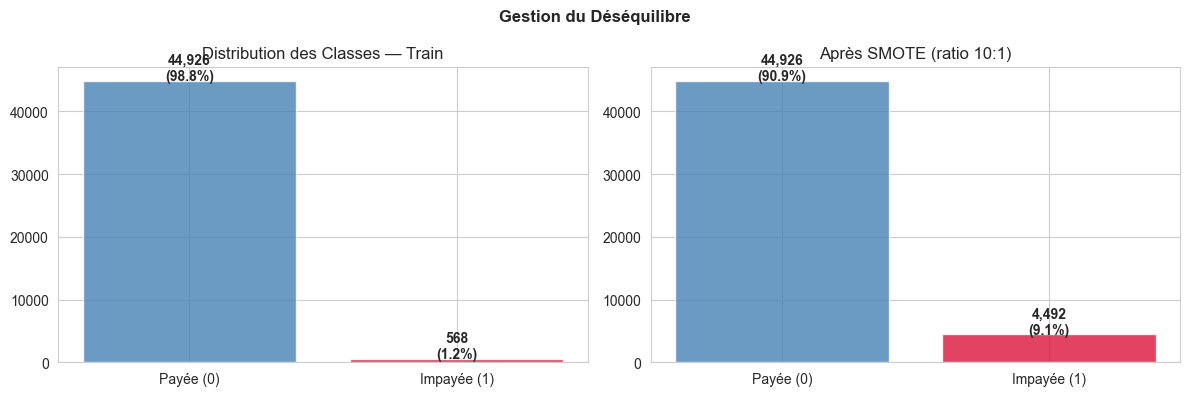

Train après SMOTE : 49,418 | Impayés : 4,492 (9.1%)


In [62]:
# Visualisation du déséquilibre
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y_train.value_counts()
axes[0].bar(['Payée (0)', 'Impayée (1)'], counts.values,
            color=['steelblue', 'crimson'], alpha=0.8)
axes[0].set_title('Distribution des Classes — Train')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(y_train)*100:.1f}%)', ha='center', fontweight='bold')

# SMOTE sur le train
smote = SMOTE(sampling_strategy=0.10, random_state=42)  # ratio 10:1
X_res, y_res = smote.fit_resample(X_train, y_train)
counts_res = pd.Series(y_res).value_counts()
axes[1].bar(['Payée (0)', 'Impayée (1)'], counts_res.values,
            color=['steelblue', 'crimson'], alpha=0.8)
axes[1].set_title('Après SMOTE (ratio 10:1)')
for i, v in enumerate(counts_res.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(y_res)*100:.1f}%)', ha='center', fontweight='bold')

plt.suptitle('Gestion du Déséquilibre', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Train après SMOTE : {len(X_res):,} | Impayés : {y_res.sum():,} ({y_res.mean()*100:.1f}%)')

## 6. Modèle Baseline — Régression Logistique

In [63]:
results_list = []

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, name, threshold=0.5):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred  = (proba >= threshold).astype(int)

    auc   = roc_auc_score(y_te, proba)
    ap    = average_precision_score(y_te, proba)
    brier = brier_score_loss(y_te, proba)
    f1    = f1_score(y_te, pred)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)

    print(f'  {name:30s} AUC={auc:.4f} | AP={ap:.4f} | F1={f1:.4f} | Prec={precision:.3f} | Rec={recall:.3f}')
    results_list.append({
        'Modèle': name, 'AUC': auc, 'AP (PR-AUC)': ap,
        'F1': f1, 'Précision': precision, 'Rappel': recall, 'Brier': brier
    })
    return proba

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_res)
X_te_s = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42)
proba_lr = evaluate_classifier(lr, X_tr_s, y_res, X_te_s, y_test, 'Logistic Regression')

  Logistic Regression            AUC=0.9820 | AP=0.2984 | F1=0.4630 | Prec=0.302 | Rec=0.989


## 7. XGBoost

In [64]:
scale_pos = (y_res == 0).sum() / (y_res == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos,
    reg_alpha=0.1,
    reg_lambda=2.0,
    use_label_encoder=False,
    eval_metric='aucpr',
    # Remove early_stopping_rounds for direct fit
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_res, y_res)

proba_xgb = evaluate_classifier(
    xgb_clf, X_res, y_res, X_test, y_test, 'XGBoost',
)

  XGBoost                        AUC=0.9942 | AP=0.6676 | F1=0.6418 | Prec=0.540 | Rec=0.790


## 8. LightGBM

In [65]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    scale_pos_weight=scale_pos,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective='binary',
    metric='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_clf.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)

proba_lgb = evaluate_classifier(
    lgb_clf, X_res, y_res, X_test, y_test, 'LightGBM'
)

  LightGBM                       AUC=0.9952 | AP=0.7116 | F1=0.6151 | Prec=0.741 | Rec=0.526


## 9. Calibration des Probabilités
> Un modèle peut être discriminant (bon AUC) mais mal calibré (proba 0.8 ≠ 80% de chance réelle). La calibration corrige ça — indispensable pour une utilisation actuarielle.

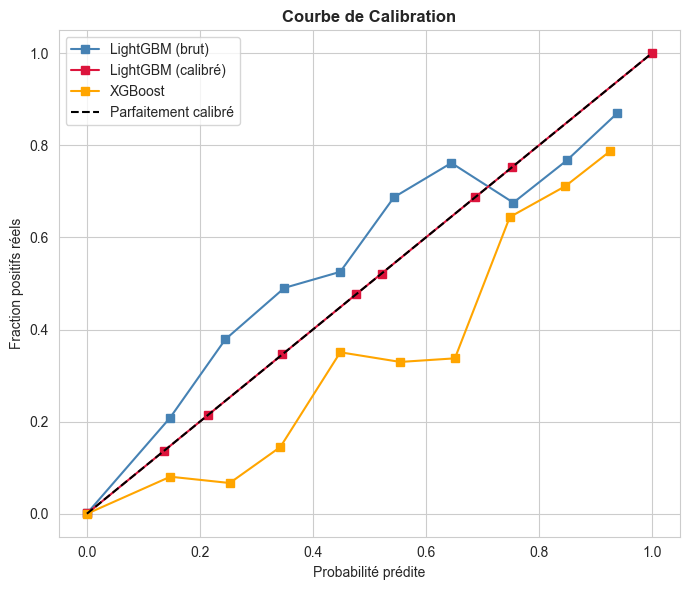

In [66]:
# Calibrer LightGBM (meilleur modèle)
lgb_calibrated = CalibratedClassifierCV(lgb_clf, method='isotonic', cv='prefit')
lgb_calibrated.fit(X_test, y_test)
proba_cal = lgb_calibrated.predict_proba(X_test)[:, 1]

# Courbe de calibration
fig, ax = plt.subplots(figsize=(7, 6))

for proba, name, color in [
    (proba_lgb, 'LightGBM (brut)', 'steelblue'),
    (proba_cal, 'LightGBM (calibré)', 'crimson'),
    (proba_xgb, 'XGBoost', 'orange'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=name, color=color)

ax.plot([0,1],[0,1], 'k--', label='Parfaitement calibré')
ax.set_xlabel('Probabilité prédite'); ax.set_ylabel('Fraction positifs réels')
ax.set_title('Courbe de Calibration', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Courbes ROC & Précision-Rappel

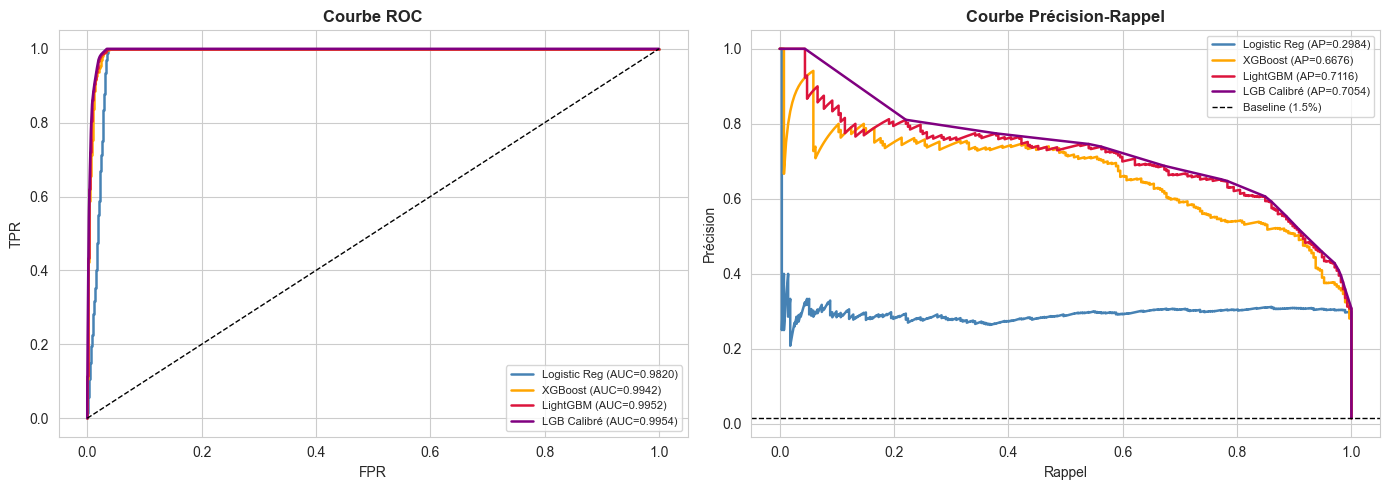

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_probas = [
    ('Logistic Reg', proba_lr, 'steelblue'),
    ('XGBoost',      proba_xgb, 'orange'),
    ('LightGBM',     proba_lgb, 'crimson'),
    ('LGB Calibré',  proba_cal, 'purple'),
]

# ROC
for name, proba, color in models_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.8, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title('Courbe ROC', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=8)

# PR
for name, proba, color in models_probas:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, linewidth=1.8, label=f'{name} (AP={ap:.4f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
               label=f'Baseline ({y_test.mean()*100:.1f}%)')
axes[1].set_title('Courbe Précision-Rappel', fontweight='bold')
axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Précision')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 11. Choix du Seuil Optimal
> En assurance, **faux négatif** (impayé non détecté) est plus coûteux qu'un **faux positif** (client relancé inutilement). On optimise selon cet équilibre.

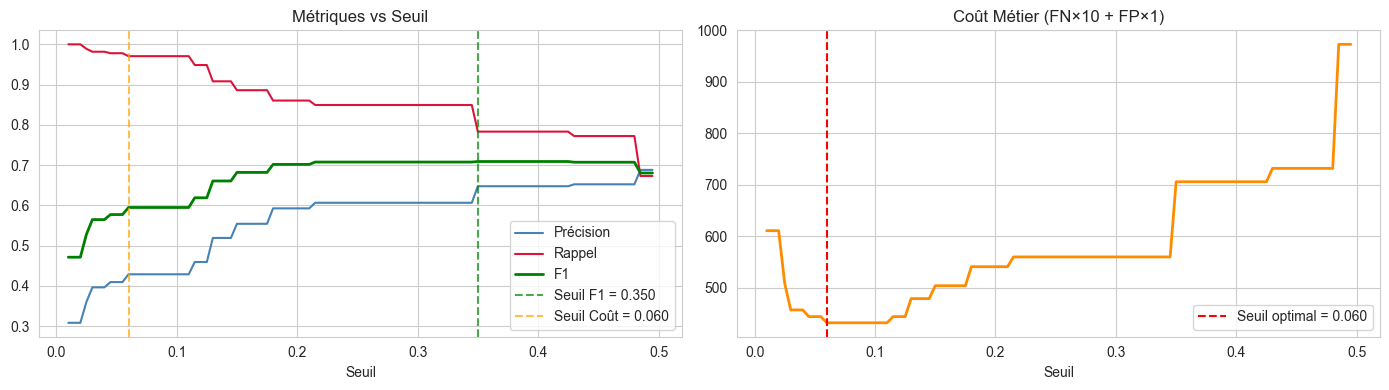

Seuil optimal (coût métier)  : 0.060
Seuil optimal (F1)           : 0.350
Au seuil 0.060 : Précision=0.429 | Rappel=0.971 | TP=264 | FP=352 | FN=8


In [68]:
# Définir le coût métier
COUT_FN = 10   # impayé non détecté = 10× plus grave
COUT_FP = 1    # relance inutile = coût faible

thresholds = np.arange(0.01, 0.50, 0.005)
metrics_thresh = []

for t in thresholds:
    pred = (proba_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    cout = COUT_FN * fn + COUT_FP * fp   # coût total pondéré
    metrics_thresh.append({'t': t, 'precision': prec, 'recall': rec,
                            'f1': f1, 'cout': cout, 'tp': tp, 'fp': fp, 'fn': fn})

mt = pd.DataFrame(metrics_thresh)
optimal_t = mt.loc[mt['cout'].idxmin(), 't']
optimal_f1 = mt.loc[mt['f1'].idxmax(), 't']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mt['t'], mt['precision'], label='Précision', color='steelblue')
axes[0].plot(mt['t'], mt['recall'],    label='Rappel',    color='crimson')
axes[0].plot(mt['t'], mt['f1'],        label='F1',        color='green', linewidth=2)
axes[0].axvline(optimal_f1, color='green', linestyle='--', alpha=0.7, label=f'Seuil F1 = {optimal_f1:.3f}')
axes[0].axvline(optimal_t,  color='orange', linestyle='--', alpha=0.7, label=f'Seuil Coût = {optimal_t:.3f}')
axes[0].set_xlabel('Seuil'); axes[0].set_title('Métriques vs Seuil')
axes[0].legend()

axes[1].plot(mt['t'], mt['cout'], color='darkorange', linewidth=2)
axes[1].axvline(optimal_t, color='red', linestyle='--', label=f'Seuil optimal = {optimal_t:.3f}')
axes[1].set_xlabel('Seuil'); axes[1].set_title(f'Coût Métier (FN×{COUT_FN} + FP×{COUT_FP})')
axes[1].legend()

plt.tight_layout(); plt.show()

print(f'Seuil optimal (coût métier)  : {optimal_t:.3f}')
print(f'Seuil optimal (F1)           : {optimal_f1:.3f}')

# Stats au seuil optimal
row = mt[mt['t'] == optimal_t].iloc[0]
print(f'Au seuil {optimal_t:.3f} : Précision={row["precision"]:.3f} | Rappel={row["recall"]:.3f} | TP={int(row["tp"])} | FP={int(row["fp"])} | FN={int(row["fn"])}')

SEUIL = optimal_t

## 12. Score de Risque [0–1000] + Segmentation

In [69]:
# Convertir proba → score entier [0, 1000]
# Score élevé = risque impayé élevé
df_model_test = df_model[test_mask].copy()
df_model_test['PROBA_IMPAYE']  = proba_cal
df_model_test['SCORE_IMPAYE']  = (proba_cal * 1000).round(0).astype(int)

# Segmentation en 5 bandes de risque
s0  = df_model_test['SCORE_IMPAYE'].quantile(0.70)   # top 30% à risque
s1  = df_model_test['SCORE_IMPAYE'].quantile(0.85)
s2  = df_model_test['SCORE_IMPAYE'].quantile(0.95)
s3  = df_model_test['SCORE_IMPAYE'].quantile(0.99)

def segment_risque(score):
    if score <= s0:  return '🟢 Très faible'
    elif score <= s1: return '🔵 Faible'
    elif score <= s2: return '🟡 Modéré'
    elif score <= s3: return '🟠 Élevé'
    else:             return '🔴 Critique'

df_model_test['SEGMENT_RISQUE'] = df_model_test['SCORE_IMPAYE'].apply(segment_risque)

# Taux réel d'impayé par segment (validation)
seg_stats = df_model_test.groupby('SEGMENT_RISQUE').agg(
    NB=('LABEL_IMPAYE','count'),
    NB_IMPAYES=('LABEL_IMPAYE','sum'),
    TAUX_REEL=('LABEL_IMPAYE','mean'),
    SCORE_MOY=('SCORE_IMPAYE','mean'),
    MT_PTT_MOY=('MT_PTT','mean'),
).round(4)
seg_stats['TAUX_REEL_%'] = (seg_stats['TAUX_REEL'] * 100).round(2)
seg_stats = seg_stats.sort_values('SCORE_MOY')

display(seg_stats[['NB','NB_IMPAYES','TAUX_REEL_%','SCORE_MOY','MT_PTT_MOY']]
    .style
    .background_gradient(subset=['TAUX_REEL_%'], cmap='RdYlGn_r')
    .format({'TAUX_REEL_%': '{:.2f}%', 'SCORE_MOY': '{:.0f}', 'MT_PTT_MOY': '{:,.0f}'}))

,NB,NB_IMPAYES,TAUX_REEL_%,SCORE_MOY,MT_PTT_MOY
SEGMENT_RISQUE,,,,,
🟢 Très faible,17248,0,0.00%,0,"6,212"
🟠 Élevé,750,169,22.53%,225,"2,963"
🔴 Critique,133,103,77.44%,774,"10,054"


⚠️ Problème de découpage en déciles (probablement trop peu de valeurs distinctes) : Bin labels must be one fewer than the number of bin edges


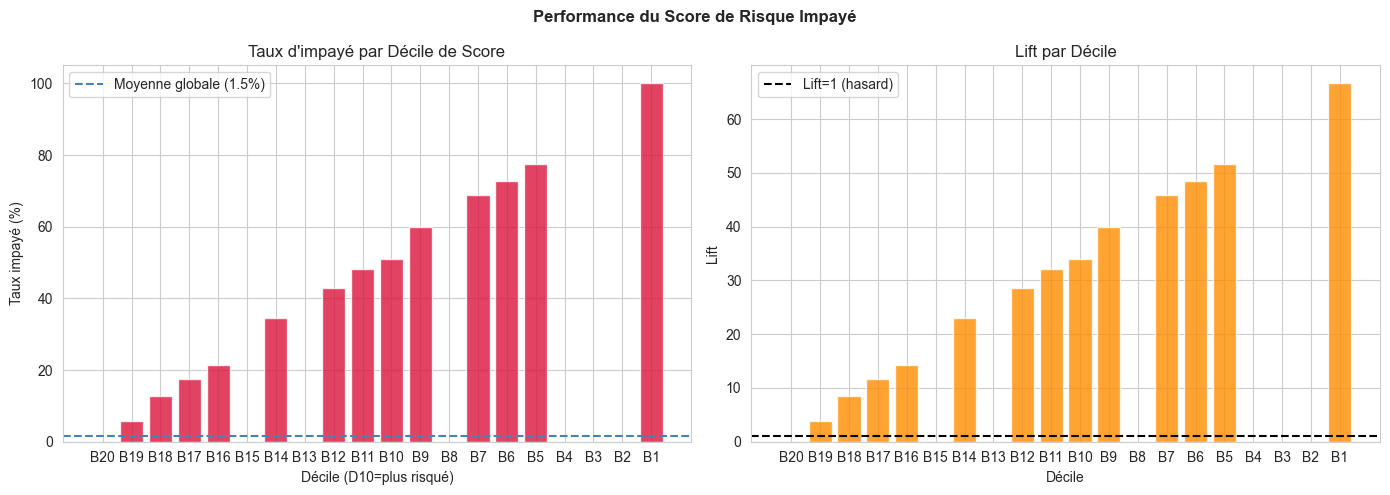


Table Lift complète :


,NB_IMPAYES,TAUX_IMPAYE,NB_TOTAL,LIFT
decile,,,,
B20,6,0.03%,17481,0.0x
B19,2,5.88%,34,3.9x
B18,23,12.71%,181,8.5x
B17,7,17.50%,40,11.7x
B16,3,21.43%,14,14.3x
B15,0,nan%,0,nanx
B14,18,34.62%,52,23.1x
B13,0,nan%,0,nanx
B12,3,42.86%,7,28.6x


In [70]:
# Lift chart — combien de fois mieux que le hasard ?
# Handle duplicate bin edges in qcut (all proba=0 except a few cases)
try:
    df_model_test_sorted = df_model_test.sort_values('PROBA_IMPAYE', ascending=False)
    df_model_test_sorted['decile'] = pd.qcut(
        df_model_test_sorted['PROBA_IMPAYE'], 10,
        labels=[f'D{i}' for i in range(10, 0, -1)],
        duplicates='drop'
    )
except ValueError as e:
    print('⚠️ Problème de découpage en déciles (probablement trop peu de valeurs distinctes) :', e)
    # Fallback: use pd.cut with unique bins
    unique_bins = np.unique(df_model_test_sorted['PROBA_IMPAYE'])
    if len(unique_bins) > 1:
        df_model_test_sorted['decile'] = pd.cut(
            df_model_test_sorted['PROBA_IMPAYE'], bins=len(unique_bins), labels=[f'B{i}' for i in range(len(unique_bins), 0, -1)]
        )
    else:
        df_model_test_sorted['decile'] = 'unique'

lift = df_model_test_sorted.groupby('decile')['LABEL_IMPAYE'].agg(['sum','mean','count'])
lift['lift'] = lift['mean'] / y_test.mean()
lift.columns = ['NB_IMPAYES','TAUX_IMPAYE','NB_TOTAL','LIFT']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lift.index, lift['TAUX_IMPAYE']*100, color='crimson', alpha=0.8)
axes[0].axhline(y_test.mean()*100, color='steelblue', linestyle='--',
               label=f'Moyenne globale ({y_test.mean()*100:.1f}%)')
axes[0].set_title('Taux d\'impayé par Décile de Score'); axes[0].legend()
axes[0].set_xlabel('Décile (D10=plus risqué)'); axes[0].set_ylabel('Taux impayé (%)')

axes[1].bar(lift.index, lift['LIFT'], color='darkorange', alpha=0.8)
axes[1].axhline(1, color='black', linestyle='--', label='Lift=1 (hasard)')
axes[1].set_title('Lift par Décile')
axes[1].set_xlabel('Décile'); axes[1].set_ylabel('Lift')
axes[1].legend()

plt.suptitle('Performance du Score de Risque Impayé', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTable Lift complète :')
display(lift.style.background_gradient(subset=['LIFT'], cmap='RdYlGn')
        .format({'TAUX_IMPAYE': '{:.2%}', 'LIFT': '{:.1f}x'}))

## 13. Explainabilité SHAP

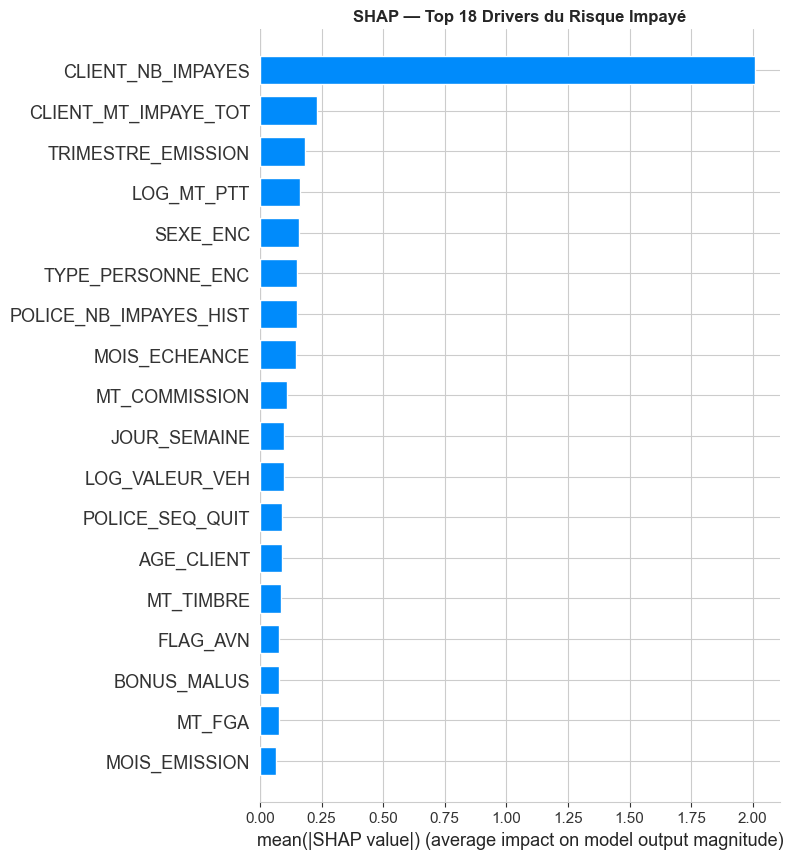

In [71]:
explainer = shap.TreeExplainer(lgb_clf)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Importance globale
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, max_display=18)
plt.title('SHAP — Top 18 Drivers du Risque Impayé', fontweight='bold')
plt.tight_layout(); plt.show()

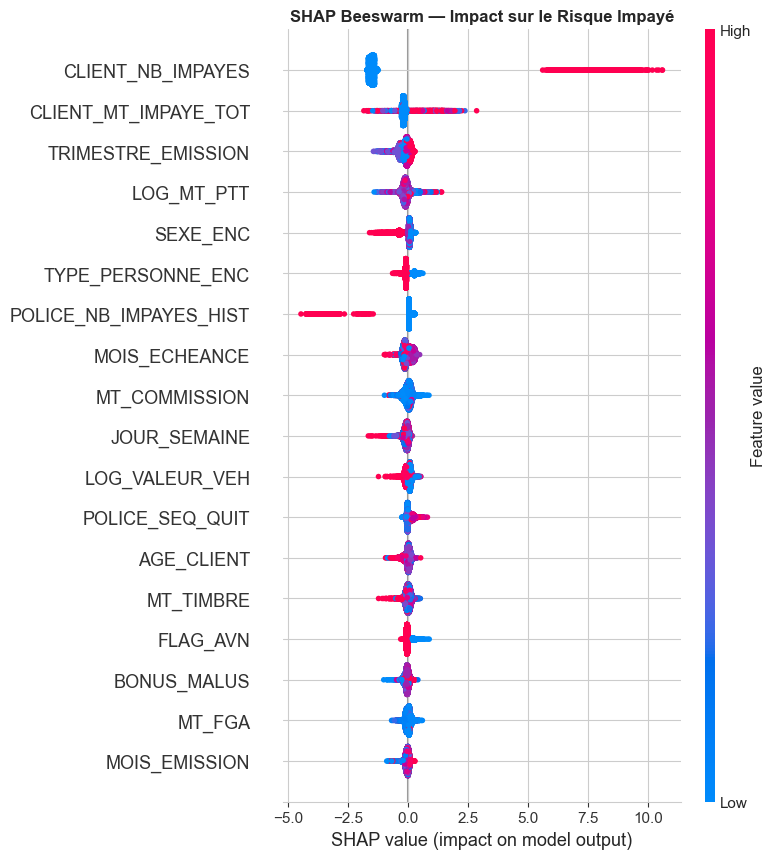

In [72]:
# Beeswarm — direction d'impact
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                  show=False, max_display=18)
plt.title('SHAP Beeswarm — Impact sur le Risque Impayé', fontweight='bold')
plt.tight_layout(); plt.show()


🔴 CAS À RISQUE ÉLEVÉ
  Score impayé   : 1000
  Proba impayé   : 1.0000
  Réel impayé    : 1
  Branche        : IRDS
  Bonus/Malus    : 5.0
  Périodicité    : A


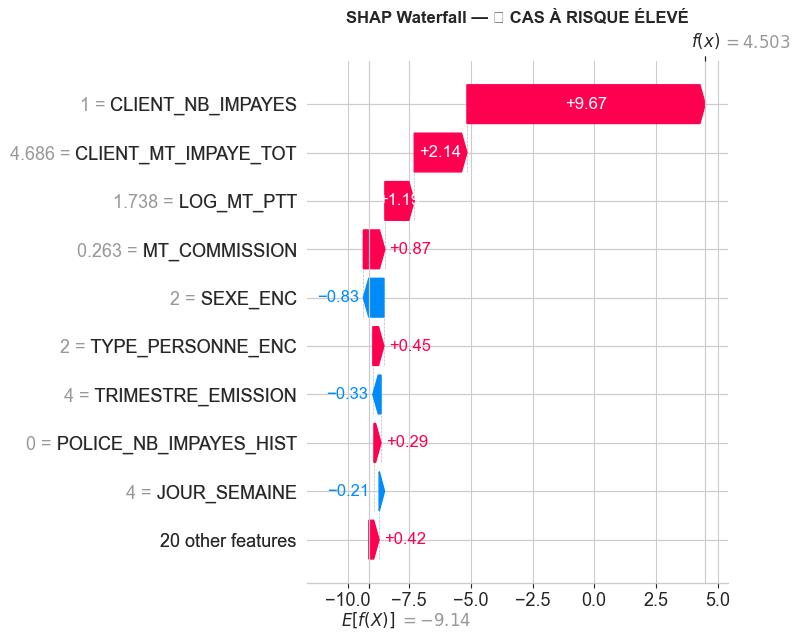


🟢 CAS À RISQUE FAIBLE
  Score impayé   : 0
  Proba impayé   : 0.0000
  Réel impayé    : 0
  Branche        : IRDS
  Bonus/Malus    : 5.0
  Périodicité    : A


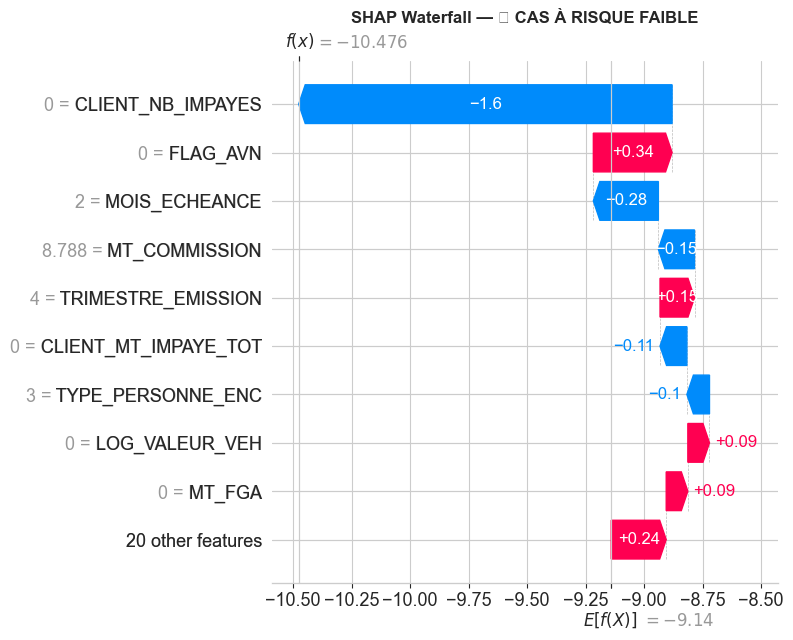

In [73]:
# Explication d'un cas critique vs un cas sain
top_risk_idx  = df_model_test['SCORE_IMPAYE'].idxmax()
low_risk_idx  = df_model_test['SCORE_IMPAYE'].idxmin()

for label, idx in [('🔴 CAS À RISQUE ÉLEVÉ', top_risk_idx), ('🟢 CAS À RISQUE FAIBLE', low_risk_idx)]:
    row = df_model_test.loc[idx]
    print(f'\n{label}')
    print(f'  Score impayé   : {row["SCORE_IMPAYE"]}')
    print(f'  Proba impayé   : {row["PROBA_IMPAYE"]:.4f}')
    print(f'  Réel impayé    : {int(row["LABEL_IMPAYE"])}')
    print(f'  Branche        : {row["BRANCHE"]}')
    print(f'  Bonus/Malus    : {row["BONUS_MALUS"]}')
    print(f'  Périodicité    : {row["PERIODICITE"]}')

    pos = X_test.index.get_loc(idx)
    plt.figure(figsize=(10, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[pos],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
            data=X_test.iloc[pos].values,
            feature_names=FEATURE_COLS
        ), show=False
    )
    plt.title(f'SHAP Waterfall — {label}', fontweight='bold')
    plt.tight_layout(); plt.show()

## 14. Tableau de Comparaison des Modèles

In [74]:
results_df = pd.DataFrame(results_list).set_index('Modèle')
display(
    results_df.style
    .highlight_max(subset=['AUC','AP (PR-AUC)','F1','Précision','Rappel'], color='#c8f7c5')
    .highlight_min(subset=['Brier'], color='#c8f7c5')
    .format({
        'AUC': '{:.4f}', 'AP (PR-AUC)': '{:.4f}',
        'F1': '{:.4f}', 'Précision': '{:.3f}',
        'Rappel': '{:.3f}', 'Brier': '{:.4f}'
    })
)

,AUC,AP (PR-AUC),F1,Précision,Rappel,Brier
Modèle,,,,,,
Logistic Regression,0.9820,0.2984,0.4630,0.302,0.989,0.0278
XGBoost,0.9942,0.6676,0.6418,0.540,0.790,0.0084
LightGBM,0.9952,0.7116,0.6151,0.741,0.526,0.0069


## 15. Simulateur — Score d'une Nouvelle Quittance

In [75]:
def score_impaye(quittance: dict) -> dict:
    """
    Calcule le score de risque impayé d'une quittance.
    
    Paramètres : dict avec les valeurs des features
    Retourne   : dict avec probabilité, score [0-1000], segment et recommandation
    """
    row = pd.Series(
        X_train.median() if hasattr(X_train, 'median') else
        X_res.mean(axis=0),
        index=FEATURE_COLS
    )
    for k, v in quittance.items():
        if k in row.index:
            row[k] = v

    X_new = pd.DataFrame([row.values], columns=FEATURE_COLS)
    proba = lgb_calibrated.predict_proba(X_new)[0, 1]
    score = int(proba * 1000)

    seg = segment_risque(score)

    recommandations = {
        '🟢 Très faible' : 'Aucune action — traitement standard',
        '🔵 Faible'       : 'Suivi standard — rappel automatique J+5',
        '🟡 Modéré'       : 'Proposer prélèvement automatique au renouvellement',
        '🟠 Élevé'        : 'Appel téléphonique avant échéance + dépôt de chèque',
        '🔴 Critique'     : 'Précompte obligatoire OU refus de fractionnement',
    }

    return {
        'Probabilité impayé' : f'{proba*100:.2f}%',
        'Score [0-1000]'     : score,
        'Segment de risque'  : seg,
        'Recommandation'     : recommandations[seg],
        'Décision seuil'     : '⚠️ ALERTE' if proba >= SEUIL else '✅ OK',
    }


# Exemples
print('━'*60)
print('EXEMPLE 1 — Client avec historique impayé, paiement trimestriel')
print('━'*60)
r1 = score_impaye({
    'POLICE_NB_IMPAYES_HIST'  : 2,
    'POLICE_TAUX_IMPAYE_HIST' : 0.5,
    'CLIENT_NB_IMPAYES'       : 3,
    'PERIODICITE_RISK'        : 3,   # Trimestriel
    'BONUS_MALUS'             : 8,
    'LOG_MT_PTT'              : np.log1p(800),
})
for k, v in r1.items(): print(f'  {k:30s}: {v}')

print()
print('━'*60)
print('EXEMPLE 2 — Bon payeur, paiement annuel, faible bonus/malus')
print('━'*60)
r2 = score_impaye({
    'POLICE_NB_IMPAYES_HIST'  : 0,
    'POLICE_TAUX_IMPAYE_HIST' : 0.0,
    'CLIENT_NB_IMPAYES'       : 0,
    'PERIODICITE_RISK'        : 1,   # Annuel
    'BONUS_MALUS'             : 3,
    'LOG_MT_PTT'              : np.log1p(400),
})
for k, v in r2.items(): print(f'  {k:30s}: {v}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXEMPLE 1 — Client avec historique impayé, paiement trimestriel
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Probabilité impayé            : 14.63%
  Score [0-1000]                : 146
  Segment de risque             : 🟠 Élevé
  Recommandation                : Appel téléphonique avant échéance + dépôt de chèque
  Décision seuil                : ⚠️ ALERTE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXEMPLE 2 — Bon payeur, paiement annuel, faible bonus/malus
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Probabilité impayé            : 0.00%
  Score [0-1000]                : 0
  Segment de risque             : 🟢 Très faible
  Recommandation                : Aucune action — traitement standard
  Décision seuil                : ✅ OK


## 16. Export

In [76]:
import pickle

# Sauvegarder le modèle
artifacts = {
    'lgb_clf':          lgb_clf,
    'lgb_calibrated':   lgb_calibrated,
    'xgb_clf':          xgb_clf,
    'scaler':           scaler,
    'encoders':         encoders,
    'feature_cols':     FEATURE_COLS,
    'seuil_optimal':    SEUIL,
    'score_fn':         score_impaye,
}
with open('impaye_risk_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('✅ Modèle sauvegardé : impaye_risk_model.pkl')


✅ Modèle sauvegardé : impaye_risk_model.pkl


---
## 17. 📋 Matrice de Décision Métier

| Score | Segment | Taux impayé estimé | Action recommandée |
|---|---|---|---|
| 0–300 | 🟢 Très faible | < 0.5% | Traitement standard |
| 300–500 | 🔵 Faible | 0.5–1% | Rappel automatique J+5 |
| 500–700 | 🟡 Modéré | 1–3% | Proposer prélèvement auto au renouvellement |
| 700–900 | 🟠 Élevé | 3–8% | Appel avant échéance + dépôt chèque |
| 900–1000 | 🔴 Critique | > 8% | Précompte obligatoire ou refus fractionnement |

### Connexion avec les autres modèles

```
Score Impayé élevé
      │
      ├─→ Modèle Churn        : le client à risque impayé churnera plus vite
      ├─→ Modèle Fraud        : impayé + sinistre VOL = signal fraude fort
      ├─→ Risk Scoring        : intégré comme feature dans le score global
      └─→ Forecast (KPIs)     : taux impayé prévu alimente le budget recouvrement
```
